
**IMPORT NECESSARY LIBRARIES**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import joblib

**DATA READING**

In [3]:

df = pd.read_csv("customer_churn.csv")

print(df.head())

print(df.info())

  CustomerID  Age  Gender        City SubscriptionType  MonthlySpending  \
0   CUST0001   58    Male      Lahore          Premium           2506.0   
1   CUST0002   65    Male    Peshawar            Basic           1267.0   
2   CUST0003   53    Male    Peshawar            Basic           5327.0   
3   CUST0004   45  Female  Faisalabad            Basic           6754.0   
4   CUST0005   40  Female  Faisalabad            Basic           4263.0   

   Tenure  NumberOfPurchases  SupportRequests  LoginFrequency  \
0      18                 29                2              24   
1       2                 28                3              17   
2      29                 36                0              25   
3      14                 44                1               3   
4      47                 69                1              30   

   LastActivityDays  SatisfactionScore Churn  
0                86                2.0   Yes  
1                 3               10.0    No  
2                

**DATA CLEANING**

In [4]:
print(df.isnull().sum())

#there is no null value

CustomerID            0
Age                   0
Gender                0
City                  0
SubscriptionType      0
MonthlySpending      40
Tenure                0
NumberOfPurchases     0
SupportRequests       0
LoginFrequency        0
LastActivityDays      0
SatisfactionScore    40
Churn                 0
dtype: int64


In [25]:
print(df.duplicated().sum())
#there is no duplication as well


0


**Exploratory Data Analysis (EDA)**

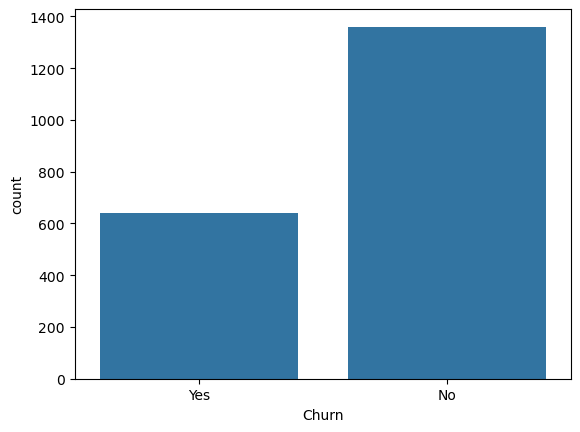

In [6]:
#Churn Distribution
sns.countplot(data=df, x="Churn")
plt.show()

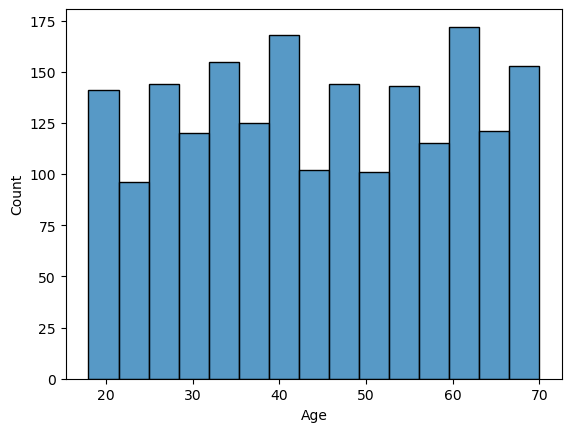

In [7]:
#Age Distribution
sns.histplot(df["Age"], bins=15)
plt.show()

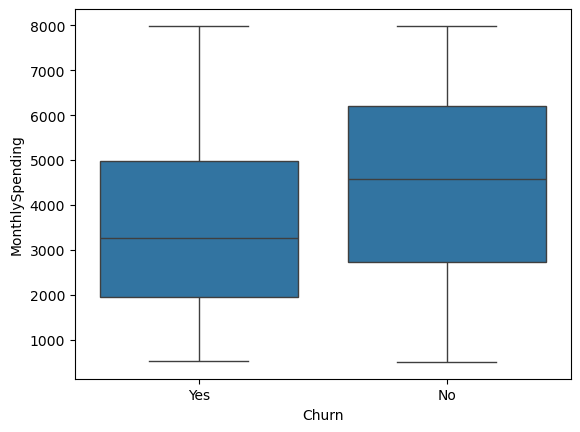

In [8]:
#Monthly Spending by Churn
sns.boxplot(data=df, x="Churn", y="MonthlySpending")
plt.show()

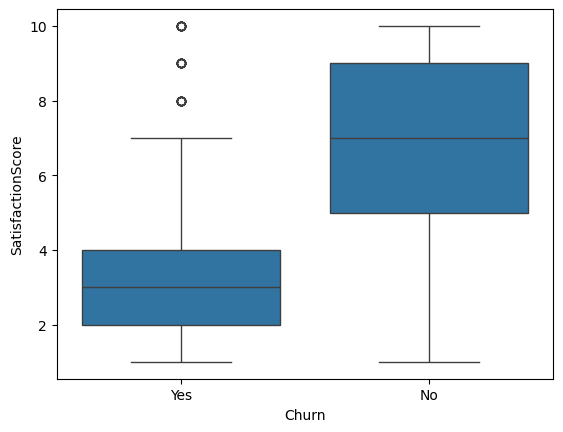

In [9]:
#Satisfaction vs Churn
sns.boxplot(data=df, x="Churn", y="SatisfactionScore")
plt.show()

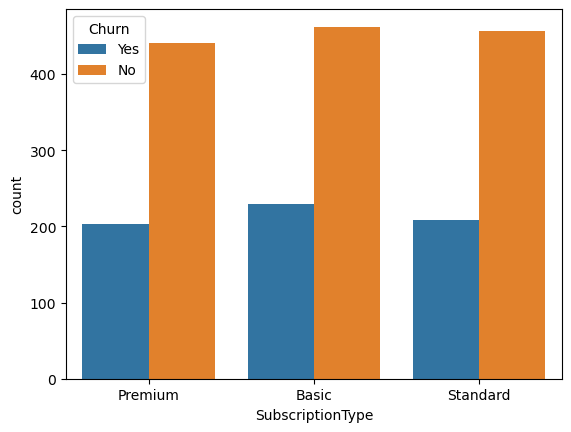

In [10]:
#Subscription Type
sns.countplot(data=df, x="SubscriptionType", hue="Churn")
plt.show()

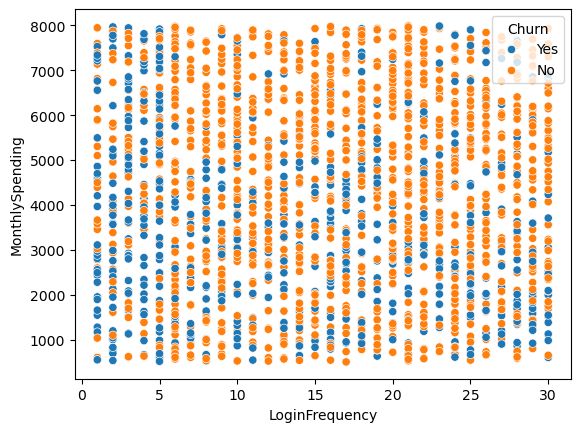

In [11]:
#Login Frequency
sns.scatterplot(
    data=df,
    x="LoginFrequency",
    y="MonthlySpending",
    hue="Churn"
)
plt.show()

**ENCODING**

In [12]:
#check categorical columns
print(df.select_dtypes(include="object").columns)

Index(['CustomerID', 'Gender', 'City', 'SubscriptionType', 'Churn'], dtype='object')


In [13]:
#Drop CustomerID because it doesn't help prediction:
df = df.drop("CustomerID", axis=1)

In [14]:
#Label Encoding
le = LabelEncoder()

categorical = [
    "Gender",
    "City",
    "SubscriptionType",
    "Churn"
]

for col in categorical:
    df[col] = le.fit_transform(df[col])

**FEATURE ENGINEERING**

In [15]:
df["AveragePurchase"] = (
    df["MonthlySpending"] /
    (df["NumberOfPurchases"] + 1)
)

df["EngagementScore"] = (
    df["LoginFrequency"] *
    df["SatisfactionScore"]
)

df["SupportPerMonth"] = (
    df["SupportRequests"] /
    (df["Tenure"] + 1)
)

**CORRELATION MATRIX**

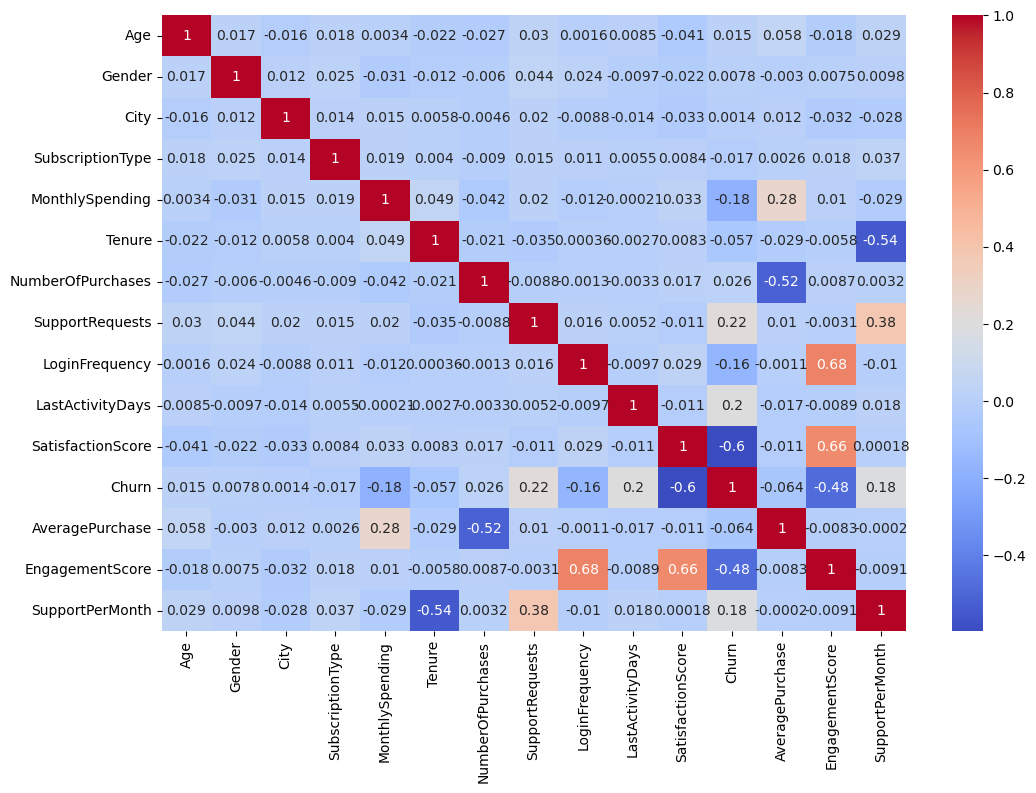

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

**TRAIN-TEST SPLIT**

In [17]:
X = df.drop("Churn", axis=1)

y = df["Churn"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**TRAIN RANDOM FOREST**

In [18]:


rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_probabilities = rf_model.predict_proba(X_test)[:,1]

**TRAIN XGBOOST**

In [19]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)

xgb_probabilities = xgb_model.predict_proba(X_test)[:,1]

**MODELS EVALUATION**

In [20]:
def evaluate_model(name, y_true, predictions, probabilities):
    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, predictions))
    print("Precision:", precision_score(y_true, predictions))
    print("Recall   :", recall_score(y_true, predictions))
    print("F1 Score :", f1_score(y_true, predictions))
    print("ROC AUC  :", roc_auc_score(y_true, probabilities))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, predictions))

    print("\nClassification Report")
    print(classification_report(y_true, predictions))

evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions,
    rf_probabilities
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_predictions,
    xgb_probabilities
)

Random Forest
Accuracy : 0.9925
Precision: 0.9921259842519685
Recall   : 0.984375
F1 Score : 0.9882352941176471
ROC AUC  : 0.9985926011029412

Confusion Matrix
[[271   1]
 [  2 126]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       272
           1       0.99      0.98      0.99       128

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400

XGBoost
Accuracy : 0.9925
Precision: 0.9921259842519685
Recall   : 0.984375
F1 Score : 0.9882352941176471
ROC AUC  : 0.9991957720588235

Confusion Matrix
[[271   1]
 [  2 126]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       272
           1       0.99      0.98      0.99       128

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99      

**SELECT XGBOOST**

Two machine learning algorithms were evaluated (Random Forest and XGBoost). XGBoost achieved the highest accuracy of 99.25%, a precision of 99.21%, a recall of 98.44%, an F1-score of 98.82%, and a ROC-AUC score of 99.89%. Based on these results, XGBoost was selected as the final model due to its superior predictive performance.

In [21]:
#save model
joblib.dump(xgb_model, "xgboost_model.pkl")

['xgboost_model.pkl']

**FEATURE IMPORTANCE**

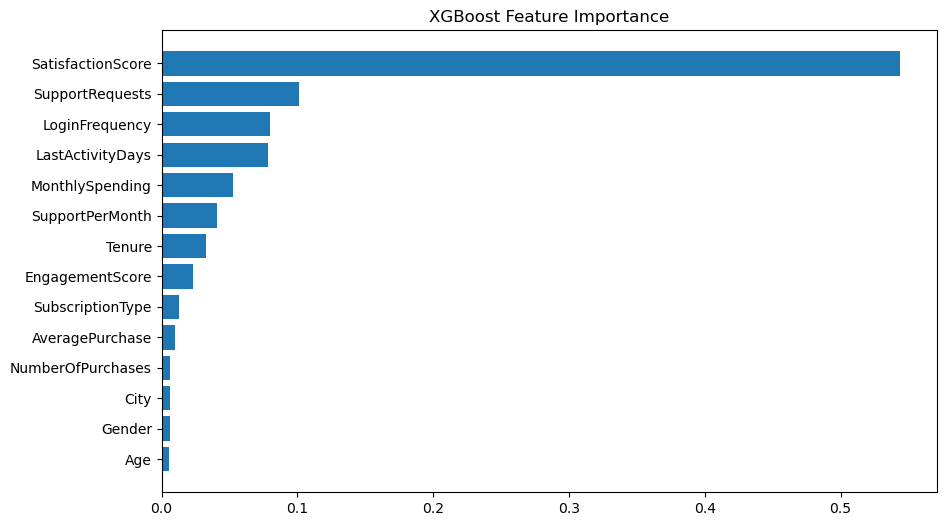

In [22]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()